In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from ISLP import load_data

In [ ]:
# Load the Caravan dataset
caravan = load_data("Caravan")

# Define features (X) and target (y)
X = caravan.drop(columns='Purchase')
y = caravan['Purchase']

In [ ]:
# Split the data into training and testing sets
# Set a random seed for reproducibility
np.random.seed(88)
train_size = int(len(X)/ 3)
train_indices = np.random.choice(len(X), train_size, replace=False)
test_indices = np.setdiff1d(np.arange(len(X)), train_indices)

X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]


In [ ]:
### QDA Model
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_train, y_train)

# Predict on the test set
qda_pred = qda_model.predict(X_test)


/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [ ]:

# Calculate the mean error and confusion matrix
qda_error = np.mean(y_test != qda_pred)
print(f"QDA Misclassification Rate: {qda_error}")
qda_cm = confusion_matrix(y_test, qda_pred)
print("QDA Confusion Matrix:")
print(qda_cm)
# Convert the confusion matrix into a DataFrame for better readability with labels
qda_cm_df = pd.DataFrame(qda_cm, index=['True: No', 'True: Yes'], columns=['Pred: No', 'Pred: Yes'])
# Print the labeled confusion matrix
print(qda_cm_df)

QDA Misclassification Rate: 0.8557444616177228
QDA Confusion Matrix:
[[ 342 3308]
 [  14  218]]
           Pred: No  Pred: Yes
True: No        342       3308
True: Yes        14        218


In [ ]:
# Extract values from the confusion matrix
TN, FP, FN, TP = qda_cm.ravel()

In [ ]:
# Calculate False Positive Rate, False Negative Rate, True Positive Rate
false_positive_rate = FP / (FP + TN)  # FPR = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)  # FNR = FN / (FN + TP)
true_positive_rate = TP / (TP + FN)   # TPR (Recall) = TP / (TP + FN)
true_negative_rate = TN / (TN + FP)   # TNR = TN / (TN + FP)
print(f"False Positive Rate (FPR): {false_positive_rate:.2f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.2f}")
print(f"True Positive Rate (TPR): {true_positive_rate:.2f}")
print(f"True Negative Rate (TNR): {true_negative_rate:.2f}")

False Positive Rate (FPR): 0.91
False Negative Rate (FNR): 0.06
True Positive Rate (TPR): 0.94
True Negative Rate (TNR): 0.09


In [ ]:
# Calculate performance metrics
accuracy = accuracy_score(y_test, qda_pred)
precision = precision_score(y_test, qda_pred, pos_label='Yes')  # Proportion of true positives all predicted positives, Precision= TP / (TP + FP)
recall = recall_score(y_test, qda_pred, pos_label='Yes')  # Proportion of true positives among actual positives. recall=TP / (TP + FN)
f1 = f1_score(y_test, qda_pred, pos_label='Yes')
#Harmonic mean of precision and recall, balancing the two: f1=2*(precision*recall)/(precision+recall)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall (TPR): {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.14
Precision: 0.06
Recall (TPR): 0.94
F1 Score: 0.12


In [ ]:
# Import necessary libraries for ROC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
# Get the probability scores of the positive class
qda_prob = qda_model.predict_proba(X_test)[:, 1]  # Probabilities of the positive class
print(qda_prob)

[1. 1. 1. ... 1. 1. 1.]


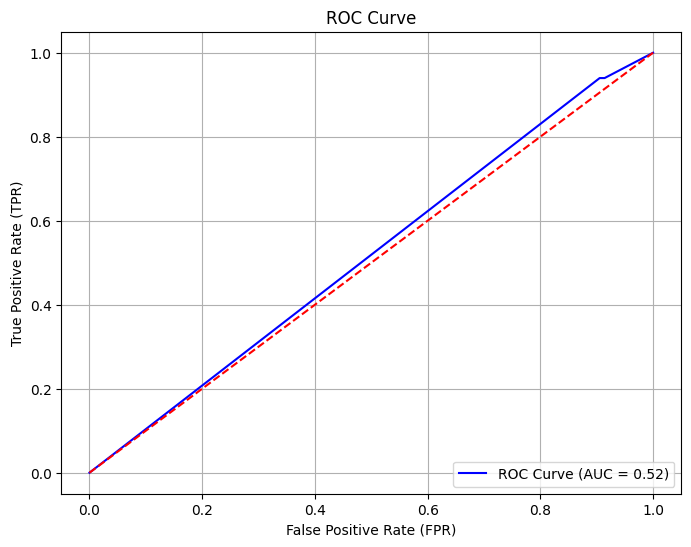

In [ ]:
# Compute ROC curve and ROC AUC score
fpr, tpr, thresholds = roc_curve(y_test, qda_prob, pos_label='Yes')
roc_auc = roc_auc_score(y_test, qda_prob)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
# Load the Smarket dataset
smarket = load_data("Smarket")

In [ ]:
# Define features (Lag1, Lag2) and target (Direction)
X = smarket[['Lag1', 'Lag2']]
y = smarket['Direction']

In [ ]:
# Split the data into training and testing sets based on the year
train = smarket['Year'] < 2005
X_train = X[train]
X_test = X[~train]
y_train = y[train]
y_test = y[~train]

In [ ]:
### LDA Model
qda_model = QuadraticDiscriminantAnalysis(reg_param=.9) #0~QDA, 1~LDA
qda_model.fit(X_train, y_train)

# Predict on the test set
qda_pred = qda_model.predict(X_test)

In [ ]:
# Probability scores for ROC curve
qda_prob = qda_model.predict_proba(X_test)[:, 1]  # Probabilities of the positive class 'Up'


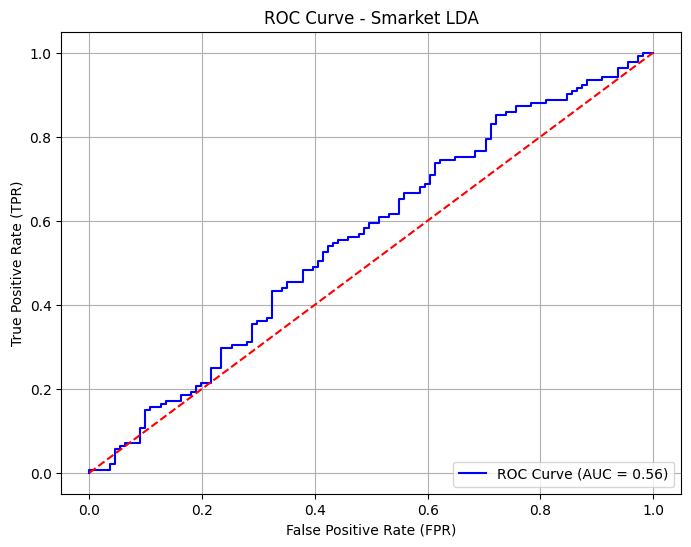

In [ ]:
# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, qda_prob, pos_label='Up')
roc_auc = roc_auc_score(y_test, qda_prob)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Smarket LDA')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
# Confusion Matrix with Labels
qda_cm = confusion_matrix(y_test, qda_pred)
qda_cm_df = pd.DataFrame(qda_cm, index=['True: Down', 'True: Up'], columns=['Pred: Down', 'Pred: Up'])
# Print the labeled confusion matrix
print("Confusion Matrix:")
print(qda_cm_df)

Confusion Matrix:
            Pred: Down  Pred: Up
True: Down          30        81
True: Up            20       121


In [ ]:
# Calculate performance metrics
accuracy = accuracy_score(y_test, qda_pred)
precision = precision_score(y_test, qda_pred, pos_label='Up')  # Adjust pos_label based on class labels
recall = recall_score(y_test, qda_pred, pos_label='Up')
f1 = f1_score(y_test, qda_pred, pos_label='Up')



In [ ]:
print("\nMetrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall (TPR): {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Metrics:
Accuracy: 0.60
Precision: 0.60
Recall (TPR): 0.86
F1 Score: 0.71
